# 08 — Predicción de Recompra (Aprendizaje Supervisado) para Instacart

Este notebook implementa un **modelo supervisado de predicción de recompra** para el dataset de Instacart.

## Objetivo
Dado el historial de compras de un usuario y el contexto de su próximo pedido, predecir qué productos **volverá a comprar**.

## Enfoque
- **Formulación**: clasificación binaria a nivel `(user_id, product_id)`.
- **Candidatos**: todos los pares únicos de usuario-producto vistos en el historial (`prior`).
- **Target**: `reordered = 1` si el producto aparece en el carrito de test (`train`), `0` en caso contrario.
- **Features**: estadísticas de usuario, producto, usuario-producto, contexto temporal del pedido, cluster de segmentación (notebook 05) y score CF (notebook 07).
- **Modelos**: Regresión Logística, HistGradientBoosting, LightGBM.
- **Métrica principal**: PR-AUC (adecuada para datasets desbalanceados) + F1 medio por pedido con umbral optimizado.

## Sección 1: Setup e Imports

Importamos todas las librerías necesarias y configuramos las constantes globales del proyecto:

- **LightGBM** (`LGBMClassifier`): modelo de gradient boosting optimizado, maneja NaN y variables categóricas nativamente.
- **HistGradientBoostingClassifier**: implementación de scikit-learn que también tolera NaN.
- **LogisticRegression**: modelo lineal de referencia que requiere imputación y escalado previo.
- **average_precision_score / roc_auc_score**: métricas de evaluación para clasificación desbalanceada.
- `RANDOM_STATE = 42`: garantiza reproducibilidad en todo el pipeline.

In [2]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.sparse import csr_matrix, load_npz
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import lightgbm as lgb
from lightgbm import LGBMClassifier
import joblib

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RAW_DIR = os.path.join('..', 'data', 'raw', 'instacart')
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
MODELS_DIR = os.path.join('..', 'models')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print('Setup completo.')
print(f'RAW_DIR      : {os.path.abspath(RAW_DIR)}')
print(f'PROCESSED_DIR: {os.path.abspath(PROCESSED_DIR)}')
print(f'MODELS_DIR   : {os.path.abspath(MODELS_DIR)}')

Setup completo.
RAW_DIR      : c:\henry\ProyectoFinal-DataScience-Henry\data\raw\instacart
PROCESSED_DIR: c:\henry\ProyectoFinal-DataScience-Henry\data\processed
MODELS_DIR   : c:\henry\ProyectoFinal-DataScience-Henry\models


## Sección 2: Carga de Datos

Cargamos los archivos raw de Instacart con dtypes optimizados para minimizar el uso de memoria:

- **orders.csv**: metadatos de cada pedido. Separamos `prior` (historial) de `train` (último carrito = ground truth de evaluación).
- **order_products__prior.csv**: productos de cada pedido histórico, incluyendo la columna `reordered` que indica si el producto fue recomprado en ese pedido.
- **order_products__train.csv**: productos del último carrito de cada usuario (solo necesitamos `order_id` y `product_id`).
- **products.csv**: nombres de productos para análisis cualitativo.

Los dtypes `int8`, `int16`, `int32` reducen el uso de memoria aproximadamente 4× respecto al default `int64`.

In [3]:
# Cargar con dtypes optimizados para memoria
orders = pd.read_csv(os.path.join(RAW_DIR, 'orders.csv'),
    usecols=['order_id','user_id','eval_set','order_number','order_dow','order_hour_of_day','days_since_prior_order'],
    dtype={'order_id': np.int32, 'user_id': np.int32, 'order_number': np.int16,
           'order_dow': np.int8, 'order_hour_of_day': np.int8})

op_prior = pd.read_csv(os.path.join(RAW_DIR, 'order_products__prior.csv'),
    usecols=['order_id','product_id','add_to_cart_order','reordered'],
    dtype={'order_id': np.int32, 'product_id': np.int32, 'add_to_cart_order': np.int16, 'reordered': np.int8})

op_train = pd.read_csv(os.path.join(RAW_DIR, 'order_products__train.csv'),
    usecols=['order_id','product_id'],
    dtype={'order_id': np.int32, 'product_id': np.int32})

products = pd.read_csv(os.path.join(RAW_DIR, 'products.csv'),
    usecols=['product_id','product_name','aisle_id','department_id'],
    dtype={'product_id': np.int32, 'aisle_id': np.int8, 'department_id': np.int8})

# Separar prior vs train
orders_prior = orders[orders['eval_set'] == 'prior'].copy()
orders_train = orders[orders['eval_set'] == 'train'][['order_id','user_id','order_dow','order_hour_of_day','days_since_prior_order']].copy()

# Unir prior con user_id y order_number
df_prior = op_prior.merge(orders_prior[['order_id','user_id','order_number']], on='order_id', how='inner')

# Ground truth: carrito real del set train
df_test_gt = op_train.merge(orders_train[['order_id','user_id']], on='order_id', how='inner')

print(f"orders shape      : {orders.shape}")
print(f"op_prior shape    : {op_prior.shape}")
print(f"df_prior shape    : {df_prior.shape}")
print(f"df_test_gt shape  : {df_test_gt.shape}")
print(f"\nPrior: {len(df_prior):,} filas, {df_prior['user_id'].nunique():,} usuarios")
print(f"Test  : {len(df_test_gt):,} filas, {df_test_gt['user_id'].nunique():,} usuarios")
print(f"Aisles únicos: {products['aisle_id'].nunique()}, Departamentos: {products['department_id'].nunique()}")

orders shape      : (3421083, 7)
op_prior shape    : (32434489, 4)
df_prior shape    : (32434489, 6)
df_test_gt shape  : (1384617, 3)

Prior: 32,434,489 filas, 206,209 usuarios
Test  : 1,384,617 filas, 131,209 usuarios
Aisles únicos: 134, Departamentos: 21


## Sección 3: Construcción de Candidatos y Target

Definimos el espacio de clasificación y etiquetamos cada ejemplo:

- **Candidatos**: todos los pares `(user_id, product_id)` únicos del historial `prior`, filtrados a usuarios que tienen un carrito `train` (son los que podemos evaluar).
- **Target `reordered = 1`**: el producto aparece en el carrito real (`op_train`).
- **Target `reordered = 0`**: el producto fue comprado antes pero NO aparece en el nuevo carrito.

**Clase desbalanceada esperada**: la tasa de positivos suele ser ~10–20%, ya que los usuarios no recompran todos sus productos históricos en cada pedido. Esto justifica el uso de PR-AUC como métrica principal y el ajuste de `class_weight='balanced'` o `scale_pos_weight`.

In [4]:
# Todos los (user_id, product_id) únicos que el usuario compró en prior
candidates = df_prior.groupby(['user_id','product_id']).size().reset_index(name='_cnt')
candidates = candidates[['user_id','product_id']]

# Filtrar: solo usuarios que tienen set 'train' (evaluables)
train_user_ids = set(df_test_gt['user_id'].unique())
candidates = candidates[candidates['user_id'].isin(train_user_ids)].copy()

# Productos recomprados en el pedido train (ground truth)
reorders_train = df_test_gt.groupby(['user_id','product_id']).size().reset_index(name='_gt')
reorders_train['reordered'] = 1

# Unir target
candidates = candidates.merge(reorders_train[['user_id','product_id','reordered']],
                               on=['user_id','product_id'], how='left')
candidates['reordered'] = candidates['reordered'].fillna(0).astype(np.int8)

pos_rate = candidates['reordered'].mean()
print(f"Filas candidatas         : {len(candidates):,}")
print(f"Usuarios                 : {candidates['user_id'].nunique():,}")
print(f"Productos únicos         : {candidates['product_id'].nunique():,}")
print(f"Tasa de positivos        : {pos_rate:.4f} ({pos_rate*100:.2f}%)")
print(f"Ratio negativo/positivo  : {(1-pos_rate)/pos_rate:.1f}x")

Filas candidatas         : 8,474,661
Usuarios                 : 131,209
Productos únicos         : 49,468
Tasa de positivos        : 0.0978 (9.78%)
Ratio negativo/positivo  : 9.2x


## Sección 4a: Features de Usuario

Construimos estadísticas agregadas por `user_id` a partir del historial `prior`. Estas features capturan **patrones de comportamiento general** del usuario:

- `u_n_orders`: cuántos pedidos tiene el usuario.
- `u_avg_basket`: tamaño promedio de su carrito.
- `u_total_items` / `u_unique_products`: volumen y diversidad de compras.
- `u_reorder_rate`: fracción de items que son recompras (muy predictivo).
- `u_avg_days` / `u_std_days`: cadencia y regularidad en los pedidos.

**Nota anti-leakage**: todos los cálculos usan exclusivamente datos `prior`. Ninguna feature proviene de `op_train`.

In [5]:
# Número de pedidos por usuario (en prior)
user_stats = orders_prior.groupby('user_id').agg(
    u_n_orders=('order_id', 'nunique'),
).reset_index()

# Tamaño promedio de carrito
basket_size = df_prior.groupby(['user_id','order_id']).size().reset_index(name='basket')
user_basket = basket_size.groupby('user_id')['basket'].agg(
    u_avg_basket='mean'
).reset_index()
del basket_size  # liberar memoria

# Estadísticas de items comprados
user_items = df_prior.groupby('user_id').agg(
    u_total_items=('product_id', 'count'),
    u_unique_products=('product_id', 'nunique'),
    u_reorder_rate=('reordered', 'mean')
).reset_index()

# Cadencia de compras (días entre pedidos)
user_cadence = orders_prior.dropna(subset=['days_since_prior_order']).groupby('user_id')['days_since_prior_order'].agg(
    u_avg_days='mean',
    u_std_days='std'
).reset_index()

# Merge progresivo
user_features = user_stats.merge(user_basket, on='user_id', how='left') \
    .merge(user_items, on='user_id', how='left') \
    .merge(user_cadence, on='user_id', how='left')

# Convertir a float32 (excepto user_id)
float_cols = [c for c in user_features.columns if c != 'user_id']
user_features[float_cols] = user_features[float_cols].astype(np.float32)

print(f"User features: {user_features.shape}")
print(f"Columnas: {list(user_features.columns)}")
print(f"NaN: {user_features.isna().sum().sum()}")

User features: (206209, 8)
Columnas: ['user_id', 'u_n_orders', 'u_avg_basket', 'u_total_items', 'u_unique_products', 'u_reorder_rate', 'u_avg_days', 'u_std_days']
NaN: 0


## Sección 4b: Features de Producto

Calculamos estadísticas agregadas por `product_id` a partir del historial `prior`. Estas features miden la **popularidad y comportamiento general** de cada producto en la plataforma:

- `p_n_orders`: cuántas veces fue pedido el producto (en total, contando múltiples compras del mismo usuario).
- `p_n_users`: cuántos usuarios distintos lo compraron (penetración).
- `p_reorder_rate`: fracción de compras que son recompras — indica si es un producto "de recurrencia" (ej. huevos) o de compra única (ej. cocina eléctrica).
- `p_avg_cart_pos`: posición promedio en el carrito — los productos que se añaden primero suelen ser más "habituales".
- `p_aisle_id` *(nuevo)*: categoría de pasillo del producto (134 aisles). Permite al modelo aprender que "el usuario compra mucho de fresh produce".
- `p_department_id` *(nuevo)*: departamento del producto (21 departamentos). Contexto semántico de mayor nivel.

In [6]:
product_features = df_prior.groupby('product_id').agg(
    p_n_orders=('order_id', 'count'),
    p_n_users=('user_id', 'nunique'),
    p_reorder_rate=('reordered', 'mean'),
    p_avg_cart_pos=('add_to_cart_order', 'mean')
).reset_index()

float_cols_p = ['p_n_orders', 'p_n_users', 'p_reorder_rate', 'p_avg_cart_pos']
product_features[float_cols_p] = product_features[float_cols_p].astype(np.float32)

# Añadir aisle_id y department_id como features categóricas
product_features = product_features.merge(
    products[['product_id', 'aisle_id', 'department_id']], on='product_id', how='left'
)
product_features['aisle_id']      = product_features['aisle_id'].astype('category')
product_features['department_id'] = product_features['department_id'].astype('category')

print(f"Product features: {product_features.shape}")
print(f"Columnas: {list(product_features.columns)}")
print(f"aisle_id  — categorías: {product_features['aisle_id'].nunique()}")
print(f"department_id — categorías: {product_features['department_id'].nunique()}")

Product features: (49677, 7)
Columnas: ['product_id', 'p_n_orders', 'p_n_users', 'p_reorder_rate', 'p_avg_cart_pos', 'aisle_id', 'department_id']
aisle_id  — categorías: 134
department_id — categorías: 21


## Sección 4c: Features Usuario-Producto (las más predictivas)

Estas features capturan la **relación específica entre un usuario y un producto** en su historial. Son las más informativas para predecir recompra porque miden directamente la lealtad del usuario a ese producto:

- `up_n_orders`: cuántas veces compró este producto específico (frecuencia absoluta).
- `up_order_rate`: fracción de sus pedidos que incluyeron este producto (frecuencia relativa).
- `up_orders_since_last`: cuántos *pedidos* han pasado desde la última compra — señal de recencia en unidad de órdenes.
- `up_days_since_last` *(nuevo)*: cuántos *días* han pasado desde la última compra del producto hasta el pedido train. Recencia en tiempo real — un usuario con `up_orders_since_last=2` y pedidos diarios es muy diferente de uno con pedidos mensuales. Se calcula reconstruyendo el tiempo acumulado con `cumsum(days_since_prior_order)`.
- `up_avg_cart_pos`: posición promedio en el carrito — los que se añaden primero son más automáticos/habituales.

> **Nota**: `up_reorder_rate` fue eliminada — tiene Gain=0 confirmado en v1.0 (multicolineal con `up_order_rate`).

In [7]:
# Agregar por (user_id, product_id) sobre datos prior
up_base = df_prior.groupby(['user_id','product_id']).agg(
    up_n_orders=('order_id', 'count'),
    up_avg_cart_pos=('add_to_cart_order', 'mean'),
    up_last_order_num=('order_number', 'max'),
    up_first_order_num=('order_number', 'min'),
).reset_index()

# Merge con n_orders de usuario para calcular tasas
up_features = up_base.merge(user_stats[['user_id','u_n_orders']], on='user_id', how='left')
up_features['up_order_rate']       = up_features['up_n_orders'] / up_features['u_n_orders']
up_features['up_orders_since_last'] = up_features['u_n_orders'] - up_features['up_last_order_num']
# up_reorder_rate eliminada: Gain=0 en v1.0 (multicolineal con up_order_rate)

up_features = up_features.drop(columns=['u_n_orders'])
float_cols_up = [c for c in up_features.columns if c not in ['user_id','product_id']]
up_features[float_cols_up] = up_features[float_cols_up].astype(np.float32)

del up_base
print(f"User-Product features: {up_features.shape}")
print(f"Columnas: {list(up_features.columns)}")

User-Product features: (13307953, 8)
Columnas: ['user_id', 'product_id', 'up_n_orders', 'up_avg_cart_pos', 'up_last_order_num', 'up_first_order_num', 'up_order_rate', 'up_orders_since_last']


### Feature `up_days_since_last` — Recencia en Días

`up_orders_since_last` cuenta cuántos *pedidos* pasaron desde la última compra, pero no captura el tiempo real. Un usuario con `up_orders_since_last=2` que compra cada 3 días es muy diferente de uno que compra cada 45 días.

**Cálculo de `up_days_since_last`:**

1. Para cada usuario, reconstruimos el tiempo acumulado en días de cada pedido prior: `cumsum(days_since_prior_order)` (NaN → 0 en el primer pedido).
2. El tiempo relativo del pedido train = días acumulados al último pedido prior + `orders_train.days_since_prior_order`.
3. Para cada par (usuario, producto), buscamos el tiempo acumulado en `up_last_order_num`.
4. `up_days_since_last = train_cum_day - last_product_cum_day`.

Esta feature captura recencia en escala temporal real — es la señal más impactful que faltaba en el modelo.

In [8]:
t0 = time.time()

# 1. Tiempo acumulado de cada pedido prior por usuario
orders_prior_sorted = orders_prior[['user_id', 'order_number', 'days_since_prior_order']].sort_values(
    ['user_id', 'order_number']
).copy()
orders_prior_sorted['dsp_filled'] = orders_prior_sorted['days_since_prior_order'].fillna(0).astype(np.float32)
orders_prior_sorted['cum_days'] = (
    orders_prior_sorted.groupby('user_id')['dsp_filled'].cumsum().astype(np.float32)
)

# 2. Tiempo acumulado del pedido train por usuario
last_prior_cum = (
    orders_prior_sorted.groupby('user_id')['cum_days']
    .max()
    .reset_index(name='last_prior_cum')
)
train_cum = last_prior_cum.merge(
    orders_train[['user_id', 'days_since_prior_order']].rename(
        columns={'days_since_prior_order': 'train_dsp'}
    ),
    on='user_id', how='left'
)
train_cum['train_cum_day'] = (
    train_cum['last_prior_cum'] + train_cum['train_dsp'].fillna(0)
).astype(np.float32)

# 3. Mapa (user_id, order_number) → cum_days
order_cumday_map = orders_prior_sorted[['user_id', 'order_number', 'cum_days']].copy()
# up_last_order_num está en float32; lo convertimos a int16 para hacer el merge
up_features['_up_last_int'] = up_features['up_last_order_num'].astype(np.int16)
order_cumday_map = order_cumday_map.rename(
    columns={'order_number': '_up_last_int', 'cum_days': '_last_prod_cum_day'}
)
order_cumday_map['_up_last_int'] = order_cumday_map['_up_last_int'].astype(np.int16)

# 4. Merge y calcular up_days_since_last
up_features = up_features.merge(order_cumday_map, on=['user_id', '_up_last_int'], how='left')
up_features = up_features.merge(train_cum[['user_id', 'train_cum_day']], on='user_id', how='left')
up_features['up_days_since_last'] = (
    up_features['train_cum_day'] - up_features['_last_prod_cum_day']
).clip(lower=0).astype(np.float32)
up_features = up_features.drop(columns=['_up_last_int', '_last_prod_cum_day', 'train_cum_day'])

del orders_prior_sorted, last_prior_cum, train_cum, order_cumday_map
print(f"up_days_since_last añadida en {time.time()-t0:.1f}s")
print(f"Stats: min={up_features['up_days_since_last'].min():.1f}  max={up_features['up_days_since_last'].max():.1f}  mean={up_features['up_days_since_last'].mean():.1f}")
print(f"NaN: {up_features['up_days_since_last'].isna().sum()}")
print(f"up_features shape: {up_features.shape}")

up_days_since_last añadida en 1.6s
Stats: min=0.0  max=365.0  mean=92.7
NaN: 0
up_features shape: (13307953, 9)


## Sección 4d: Contexto del Pedido Target

Incorporamos información temporal del pedido `train` (el que queremos predecir):

- `o_dow`: día de la semana del pedido (0=lunes, 6=domingo) — algunos productos se compran más en días específicos.
- `o_hour`: hora del día — compras nocturnas vs. matutinas pueden tener patrones distintos.
- `o_days_since`: días desde el último pedido — un intervalo largo puede aumentar la probabilidad de recomprar más productos.

**¿Es esto leakage?** No. Estas variables describen **cuándo** ocurre el pedido (contexto conocido de antemano), no **qué** productos se compraron. El contenido del carrito (`op_train`) nunca se usa como feature, solo como target (`reordered`).

In [9]:
# Timing del pedido train: dow, hour, days_since_prior
# Estas features describen CUÁNDO compra el usuario (conocido de antemano),
# NO qué compra → NO es leakage
order_context = orders_train.rename(columns={
    'order_dow': 'o_dow',
    'order_hour_of_day': 'o_hour',
    'days_since_prior_order': 'o_days_since'
})
# Quedarse solo con user_id + las 3 features de timing
order_context = order_context[['user_id','o_dow','o_hour','o_days_since']].copy()
order_context['o_dow'] = order_context['o_dow'].astype(np.int8)
order_context['o_hour'] = order_context['o_hour'].astype(np.int8)
order_context['o_days_since'] = order_context['o_days_since'].astype(np.float32)

print(f"Order context: {order_context.shape}")
print(f"Columnas: {list(order_context.columns)}")
print(f"NaN en o_days_since: {order_context['o_days_since'].isna().sum()}")

Order context: (131209, 4)
Columnas: ['user_id', 'o_dow', 'o_hour', 'o_days_since']
NaN en o_days_since: 0


## Sección 4e: Features de Integración con Modelos Previos

Incorporamos artefactos generados en notebooks anteriores para enriquecer el modelo supervisado:

### Cluster de Segmentación (Notebook 05)
El `u_cluster` asigna cada usuario a un segmento de comportamiento de compra (frecuencia, tamaño de carrito, tasa de recompra, etc.). Permite al modelo aprender patrones distintos por tipo de usuario.

### Score CF — Item-Item Similarity (Notebook 07)
El `cf_score` es la puntuación de similitud colaborativa para el par `(usuario, producto)`: cuánto recomendaría el sistema CF comprar ese producto basándose en el historial del usuario.

**Construcción eficiente**: cargamos el modelo CF (`cf_best_model.pkl`) y la matriz de similitud (`cf_item_similarity.npz`), y reconstruimos el vector usuario-item a partir de los datos `prior` (los mismos filtros del notebook 07: productos con ≥50 compras, usuarios con ≥5 pedidos). Luego calculamos `cf_score = user_vec @ item_similarity` en batches para evitar OOM.

In [10]:
# --- u_cluster: segmento del usuario (de clustering notebook 05) ---
user_seg = pd.read_parquet(os.path.join(PROCESSED_DIR, 'user_segments.parquet'))[['cluster']].reset_index()
user_seg.columns = ['user_id', 'u_cluster']
user_seg['u_cluster'] = user_seg['u_cluster'].astype(np.int8)
print(f"user_segments cargado: {user_seg.shape}, clusters: {sorted(user_seg['u_cluster'].unique())}")

# --- Cargar modelo CF y similitud item-item (Notebook 07) ---
cf_model = joblib.load(os.path.join(MODELS_DIR, 'cf_best_model.pkl'))
item_similarity = load_npz(os.path.join(PROCESSED_DIR, 'cf_item_similarity.npz'))

# Mappings del CF (productos filtrados con >=50 compras, usuarios con >=5 pedidos)
cf_user_to_idx    = cf_model['user_to_idx']     # user_id (int64) → idx
cf_product_to_idx = cf_model['product_to_idx']  # product_id (int64) → idx
cf_idx_to_product = cf_model['idx_to_product']  # idx → product_id

print(f"CF item_similarity shape: {item_similarity.shape}")
print(f"Usuarios en CF: {len(cf_user_to_idx):,}")
print(f"Productos en CF: {len(cf_product_to_idx):,}")

user_segments cargado: (162633, 2), clusters: [np.int8(0), np.int8(1), np.int8(2)]
CF item_similarity shape: (26686, 26686)
Usuarios en CF: 162,632
Productos en CF: 26,686


### Reconstrucción de la Matriz User-Item para CF Scores

Para calcular `cf_score = user_vec @ item_similarity`, necesitamos el vector del usuario en el espacio de productos CF. Reconstruimos la matriz `user_item_sparse` aplicando los mismos filtros del Notebook 07 (MIN_PRODUCT_PURCHASES=50, MIN_USER_ORDERS=5) y usando `log1p(count)` como valor. Luego calculamos los scores en **batches vectorizados** para eficiencia de memoria.

In [11]:
# Reconstruir user_item_sparse con los mismos filtros del Notebook 07
print("Reconstruyendo user_item_sparse para CF scores...")
t0 = time.time()

# Filtrar df_prior a productos y usuarios que están en el CF
df_prior_cf = df_prior[
    df_prior['product_id'].astype(np.int64).isin(cf_product_to_idx) &
    df_prior['user_id'].astype(np.int64).isin(cf_user_to_idx)
][['user_id','product_id']].copy()

# Conteo de compras por (user, product)
upc = df_prior_cf.groupby(['user_id','product_id']).size().reset_index(name='count')

# Construir sparse usando los índices del CF
n_users_cf = len(cf_user_to_idx)
n_prods_cf = len(cf_product_to_idx)

rows_cf = upc['user_id'].astype(np.int64).map(cf_user_to_idx).values
cols_cf = upc['product_id'].astype(np.int64).map(cf_product_to_idx).values
vals_cf = np.log1p(upc['count'].values).astype(np.float32)

user_item_cf = csr_matrix((vals_cf, (rows_cf, cols_cf)),
                           shape=(n_users_cf, n_prods_cf))

del df_prior_cf, upc  # liberar memoria
print(f"user_item_cf shape: {user_item_cf.shape}")
print(f"Reconstruida en {time.time()-t0:.1f}s")

# Calcular cf_scores para los candidatos en batches vectorizados
print("\nCalculando cf_scores en batches...")
t0 = time.time()

# Filtrar candidatos a usuarios que están en el CF
cands_in_cf = candidates[candidates['user_id'].astype(np.int64).isin(cf_user_to_idx)].copy()
users_in_cf = cands_in_cf['user_id'].astype(np.int64).unique()

cf_score_records = []
BATCH = 500  # batch de usuarios

for i in range(0, len(users_in_cf), BATCH):
    batch_users = users_in_cf[i:i+BATCH]
    batch_idx = [cf_user_to_idx[u] for u in batch_users]

    # user_item_cf[batch_idx] @ item_similarity: (batch × n_cf_prods)
    user_vecs = user_item_cf[batch_idx]   # sparse (batch × n_cf_prods)
    scores = (user_vecs @ item_similarity).toarray()  # dense (batch × n_cf_prods)

    for j, uid in enumerate(batch_users):
        user_cands = cands_in_cf[cands_in_cf['user_id'] == uid]['product_id'].astype(np.int64).values
        for pid in user_cands:
            if pid in cf_product_to_idx:
                pidx = cf_product_to_idx[pid]
                cf_score_records.append({'user_id': int(uid), 'product_id': int(pid),
                                         'cf_score': float(scores[j, pidx])})

    if i % (BATCH * 20) == 0:
        elapsed = time.time() - t0
        print(f"  Usuarios procesados: {min(i+BATCH, len(users_in_cf)):,}/{len(users_in_cf):,} ({elapsed:.0f}s)")

df_cf_scores = pd.DataFrame(cf_score_records)
if len(df_cf_scores) > 0:
    df_cf_scores['cf_score'] = df_cf_scores['cf_score'].astype(np.float32)
    df_cf_scores['user_id'] = df_cf_scores['user_id'].astype(np.int32)
    df_cf_scores['product_id'] = df_cf_scores['product_id'].astype(np.int32)

print(f"\nCF scores calculados en {time.time()-t0:.0f}s")
print(f"Pares con cf_score: {len(df_cf_scores):,}")

Reconstruyendo user_item_sparse para CF scores...
user_item_cf shape: (162632, 26686)
Reconstruida en 7.7s

Calculando cf_scores en batches...
  Usuarios procesados: 500/103,470 (3s)
  Usuarios procesados: 10,500/103,470 (66s)
  Usuarios procesados: 20,500/103,470 (129s)
  Usuarios procesados: 30,500/103,470 (194s)
  Usuarios procesados: 40,500/103,470 (259s)
  Usuarios procesados: 50,500/103,470 (325s)
  Usuarios procesados: 60,500/103,470 (391s)
  Usuarios procesados: 70,500/103,470 (459s)
  Usuarios procesados: 80,500/103,470 (526s)
  Usuarios procesados: 90,500/103,470 (594s)
  Usuarios procesados: 100,500/103,470 (664s)

CF scores calculados en 688s
Pares con cf_score: 7,602,135


## Sección 4f: Merge Final de Features

Ensamblamos el dataset de entrenamiento uniendo todas las features en los candidatos. El join es siempre `left` para mantener todos los pares candidatos, con NaN para valores faltantes:

- Usuarios sin segmento (fuera del rango del notebook 05): `u_cluster = -1`.
- Productos/usuarios fuera del CF (< 50 compras o < 5 pedidos): `cf_score = NaN` (los modelos de árbol lo manejan nativamente).

El dataset final tiene una fila por par `(user_id, product_id)` candidato, con todas las features y el target `reordered`.

In [12]:
# Merge progresivo con candidates como base
df = candidates.copy()
df = df.merge(user_features, on='user_id', how='left')
df = df.merge(product_features, on='product_id', how='left')
df = df.merge(up_features, on=['user_id','product_id'], how='left')
df = df.merge(order_context, on='user_id', how='left')
df = df.merge(user_seg, on='user_id', how='left')
df['u_cluster'] = df['u_cluster'].fillna(-1).astype(np.int8)

if len(df_cf_scores) > 0:
    df = df.merge(df_cf_scores, on=['user_id','product_id'], how='left')
else:
    df['cf_score'] = np.nan
# cf_score NaN para pares fuera del espacio CF (LightGBM/HistGB lo manejan nativamente)

# Lista de features (excluir IDs y target)
feature_cols = [c for c in df.columns if c not in ['user_id','product_id','reordered']]

print(f"Shape final del dataset: {df.shape}")
print(f"\nFeatures ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  {col}")

print(f"\nNaN por columna (top 10):")
nan_counts = df[feature_cols].isna().sum().sort_values(ascending=False)
print(nan_counts.head(10).to_string())

Shape final del dataset: (8474661, 28)

Features (25):
  u_n_orders
  u_avg_basket
  u_total_items
  u_unique_products
  u_reorder_rate
  u_avg_days
  u_std_days
  p_n_orders
  p_n_users
  p_reorder_rate
  p_avg_cart_pos
  aisle_id
  department_id
  up_n_orders
  up_avg_cart_pos
  up_last_order_num
  up_first_order_num
  up_order_rate
  up_orders_since_last
  up_days_since_last
  o_dow
  o_hour
  o_days_since
  u_cluster
  cf_score

NaN por columna (top 10):
cf_score             872526
u_avg_basket              0
u_total_items             0
u_unique_products         0
u_reorder_rate            0
u_avg_days                0
u_std_days                0
p_n_orders                0
u_n_orders                0
p_n_users                 0


## Sección 5: Split por Usuario (Train / Validación)

Dividimos el dataset en **train (80%)** y **validación (20%)** a nivel de usuario. Es decir, todos los pares `(user, product)` de un mismo usuario van al mismo split:

- **¿Por qué split por usuario y no por fila?** Porque el objetivo final es predecir el carrito completo de cada usuario. Si mezcláramos filas del mismo usuario entre train y val, el modelo aprendería información del mismo usuario que luego "predice" → optimismo artificial.
- La verificación `assert` garantiza que no hay ningún usuario en ambos splits (leakage de usuario).

El `pos_rate` debería ser similar en train y val (muestreo aleatorio, sin stratify por usuario necesario).

In [13]:
rng = np.random.RandomState(RANDOM_STATE)
all_train_users = df['user_id'].unique()
n_val = int(len(all_train_users) * 0.2)

val_users = set(rng.choice(all_train_users, size=n_val, replace=False))
train_users_set = set(all_train_users) - val_users

df_train = df[df['user_id'].isin(train_users_set)].copy()
df_val   = df[df['user_id'].isin(val_users)].copy()

# Verificar que no hay overlap entre train y val
assert len(set(df_train['user_id']) & set(df_val['user_id'])) == 0, "Leakage de usuarios!"
print("Split verificado: sin overlap de usuarios entre train y val.")

print(f"\nTrain: {len(df_train):,} filas, {len(train_users_set):,} usuarios, pos_rate={df_train['reordered'].mean():.4f}")
print(f"Val  : {len(df_val):,} filas,   {len(val_users):,} usuarios, pos_rate={df_val['reordered'].mean():.4f}")

X_train = df_train[feature_cols]
y_train = df_train['reordered']
X_val   = df_val[feature_cols]
y_val   = df_val['reordered']

print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}")

Split verificado: sin overlap de usuarios entre train y val.

Train: 6,777,778 filas, 104,968 usuarios, pos_rate=0.0979
Val  : 1,696,883 filas,   26,241 usuarios, pos_rate=0.0973

X_train: (6777778, 25), X_val: (1696883, 25)


## Sección 6: Preprocesamiento por Modelo

Cada modelo tiene requisitos distintos de preprocesamiento:

- **LightGBM**: `aisle_id`, `department_id` y `u_cluster` como dtype `category`. LightGBM aprende splits óptimos por categoría sin one-hot encoding.
- **HistGradientBoosting**: `aisle_id`, `department_id` y `u_cluster` como `pd.Categorical`. Con `categorical_features='from_dtype'` en sklearn ≥ 1.2, detecta automáticamente las columnas categóricas.
- **Regresión Logística**: requiere imputación de NaN (mediana) + escalado (StandardScaler). Las columnas categóricas (`aisle_id`, `department_id`) se convierten a entero (tratadas ordinalmente); `u_cluster` sigue con one-hot encoding explícito. Se agrega flag `cf_score_missing` para preservar información de ausencia de CF score.

El pipeline de sklearn garantiza que imputación y escalado se calculan **solo sobre train** y se aplican consistentemente sobre val.

In [14]:
CAT_COLS = ['u_cluster', 'aisle_id', 'department_id']

# ── LightGBM: category dtype para todas las columnas categóricas ───────────────
X_train_lgb = X_train.copy()
X_val_lgb   = X_val.copy()
for col in CAT_COLS:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_val_lgb[col]   = X_val_lgb[col].astype('category')

# ── HistGB: pd.Categorical + categorical_features='from_dtype' ────────────────
X_train_hgb = X_train.copy()
X_val_hgb   = X_val.copy()
for col in CAT_COLS:
    X_train_hgb[col] = X_train_hgb[col].astype('category')
    X_val_hgb[col]   = X_val_hgb[col].astype('category')

# ── Regresión Logística: imputación + escalado ────────────────────────────────
# Excluir u_cluster (se one-hotea después) — aisle_id y department_id van como int
num_cols = [c for c in feature_cols if c != 'u_cluster']

X_train_lr = X_train[num_cols].copy()
X_val_lr   = X_val[num_cols].copy()

# Convertir aisle_id y department_id a int para el pipeline
for col in ['aisle_id', 'department_id']:
    X_train_lr[col] = X_train_lr[col].astype(np.int16)
    X_val_lr[col]   = X_val_lr[col].astype(np.int16)

# Flag de NaN para cf_score
X_train_lr['cf_score_missing'] = X_train_lr['cf_score'].isna().astype(np.int8)
X_val_lr['cf_score_missing']   = X_val_lr['cf_score'].isna().astype(np.int8)

# One-hot encoding para u_cluster
cluster_dummies_train = pd.get_dummies(X_train['u_cluster'].astype(str), prefix='cluster')
cluster_dummies_val   = pd.get_dummies(X_val['u_cluster'].astype(str), prefix='cluster')
cluster_dummies_val   = cluster_dummies_val.reindex(columns=cluster_dummies_train.columns, fill_value=0)

X_train_lr = pd.concat([X_train_lr.reset_index(drop=True), cluster_dummies_train.reset_index(drop=True)], axis=1)
X_val_lr   = pd.concat([X_val_lr.reset_index(drop=True),   cluster_dummies_val.reset_index(drop=True)],   axis=1)

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=RANDOM_STATE, C=0.1, solver='lbfgs'))
])

print(f"X_train_lgb shape : {X_train_lgb.shape}")
print(f"X_train_hgb shape : {X_train_hgb.shape}")
print(f"X_train_lr  shape : {X_train_lr.shape}")
print(f"Categóricas en lgb/hgb: {CAT_COLS}")

X_train_lgb shape : (6777778, 25)
X_train_hgb shape : (6777778, 25)
X_train_lr  shape : (6777778, 29)
Categóricas en lgb/hgb: ['u_cluster', 'aisle_id', 'department_id']


## Sección 7: Modelo A — Regresión Logística (Baseline Lineal)

La Regresión Logística es nuestro baseline lineal. Sus ventajas:
- Rápido de entrenar e interpretar (los coeficientes muestran dirección y magnitud del efecto de cada feature).
- Sirve como piso de comparación: si los modelos no-lineales no lo superan, el problema es lineal o hay un bug.

Usamos `class_weight='balanced'` para compensar el desbalance de clases (~10:1 negativo/positivo), lo que equivale a sobre-muestrear los positivos durante el entrenamiento.

La métrica principal es **PR-AUC** (Average Precision), preferida sobre ROC-AUC en datasets desbalanceados porque no se infla artificialmente con los verdaderos negativos.

In [15]:
print("Entrenando Regresión Logística...")
t0 = time.time()
lr_pipeline.fit(X_train_lr, y_train)
time_lr = time.time() - t0
print(f"Tiempo de entrenamiento: {time_lr:.1f}s")

y_prob_lr = lr_pipeline.predict_proba(X_val_lr)[:, 1]
pr_auc_lr  = average_precision_score(y_val, y_prob_lr)
roc_auc_lr = roc_auc_score(y_val, y_prob_lr)

print(f"\nLogistic Regression:")
print(f"  PR-AUC  : {pr_auc_lr:.4f}")
print(f"  ROC-AUC : {roc_auc_lr:.4f}")

Entrenando Regresión Logística...
Tiempo de entrenamiento: 35.6s

Logistic Regression:
  PR-AUC  : 0.3903
  ROC-AUC : 0.8234


## Sección 8: Modelo B — HistGradientBoostingClassifier

`HistGradientBoostingClassifier` es la implementación de sklearn de gradient boosting por histograma (similar a LightGBM). Sus ventajas clave:

- **Manejo nativo de NaN**: no necesita imputación previa — internamente aprende la dirección óptima para valores faltantes.
- **`categorical_features='from_dtype'`** (sklearn ≥ 1.2): detecta automáticamente las columnas con dtype `pd.Categorical` y aplica splits óptimos por categoría. Usamos esto para `u_cluster`, `aisle_id` y `department_id`.
- **Rápido**: usa histogramas para discretizar features continuas.
- **`class_weight='balanced'`**: compensa el desbalance de clases (~10:1).

Configuramos `max_iter=200` y `max_leaf_nodes=63` como valores comparables al LightGBM baseline.

In [16]:
print("Entrenando HistGradientBoostingClassifier...")
t0 = time.time()
hgb = HistGradientBoostingClassifier(
    class_weight='balanced',
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=63,
    categorical_features='from_dtype',
    random_state=RANDOM_STATE
)
hgb.fit(X_train_hgb, y_train)
time_hgb = time.time() - t0
print(f"Tiempo de entrenamiento: {time_hgb:.1f}s")

y_prob_hgb  = hgb.predict_proba(X_val_hgb)[:, 1]
pr_auc_hgb  = average_precision_score(y_val, y_prob_hgb)
roc_auc_hgb = roc_auc_score(y_val, y_prob_hgb)

print(f"\nHistGradientBoosting:")
print(f"  PR-AUC  : {pr_auc_hgb:.4f}")
print(f"  ROC-AUC : {roc_auc_hgb:.4f}")

Entrenando HistGradientBoostingClassifier...
Tiempo de entrenamiento: 92.2s

HistGradientBoosting:
  PR-AUC  : 0.4263
  ROC-AUC : 0.8365


## Sección 9: Modelo C — LightGBM

LightGBM es el modelo principal para este problema. Mejoras en esta versión (v1.1):

- **`n_estimators=300`**: valor que ya demostró buen desempeño en v1.0. Las nuevas features (`up_days_since_last`, `aisle_id`, `department_id`) aportan señal adicional sin necesidad de más árboles.
- **`num_leaves=63`**: se mantiene el valor original — aumentarlo a 127 con `aisle_id` (134 categorías) causó overfitting inmediato en experimentos previos.
- **Categóricas nativas**: `u_cluster`, `aisle_id` y `department_id` pasados con `categorical_feature` en `fit()`. LightGBM aplica splits de categorías como bitmaps, capturando combinaciones sin necesidad de one-hot encoding.
- **`scale_pos_weight`**: ratio negativo/positivo para compensar el desbalance de clases (~10:1).

In [17]:
pos_ratio = float((y_train == 0).sum()) / float((y_train == 1).sum())

print(f"scale_pos_weight (ratio neg/pos): {pos_ratio:.2f}")
print("Entrenando LightGBM...")
t0 = time.time()
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    scale_pos_weight=pos_ratio,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgbm.fit(
    X_train_lgb, y_train,
    categorical_feature=CAT_COLS
)
time_lgb = time.time() - t0
print(f"Tiempo de entrenamiento: {time_lgb:.1f}s")

y_prob_lgb  = lgbm.predict_proba(X_val_lgb)[:, 1]
pr_auc_lgb  = average_precision_score(y_val, y_prob_lgb)
roc_auc_lgb = roc_auc_score(y_val, y_prob_lgb)

print(f"\nLightGBM:")
print(f"  PR-AUC  : {pr_auc_lgb:.4f}")
print(f"  ROC-AUC : {roc_auc_lgb:.4f}")

scale_pos_weight (ratio neg/pos): 9.21
Entrenando LightGBM...
Tiempo de entrenamiento: 54.4s

LightGBM:
  PR-AUC  : 0.4260
  ROC-AUC : 0.8366


## Sección 10: Optimización del Umbral de Decisión

Los modelos producen **probabilidades**, no predicciones binarias. La elección del umbral de clasificación (por defecto 0.5) afecta directamente el balance entre precisión y recall.

### F1 medio por pedido

La métrica de negocio relevante no es el F1 global, sino el **F1 promedio por usuario** (carrito):

- Para cada usuario, calculamos el F1 entre su carrito real y su carrito predicho.
- Luego promediamos sobre todos los usuarios del val set.

Esto refleja la experiencia real: queremos que la predicción de cada carrito individual sea buena, no solo el desempeño promedio sobre millones de filas sin estructura.

**Barremos umbrales** de 0.05 a 0.88 para encontrar el que maximiza esta métrica.

Mejor modelo por PR-AUC: HistGB (0.4263)

Resumen de PR-AUC:
  HistGB      : 0.4263 <-- MEJOR
  LightGBM    : 0.4260
  LogReg      : 0.3903

Optimizando umbral sobre 43 valores...
Completado en 0.4s

Umbral óptimo          : 0.690
F1 medio por pedido    : 0.3815


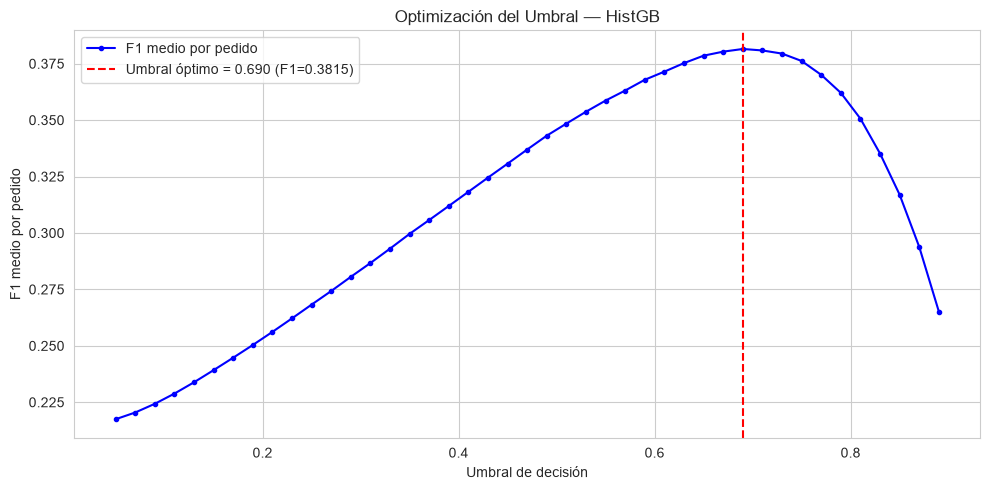

In [18]:
# Determinar mejor modelo por PR-AUC
model_scores = {
    'LogReg': (pr_auc_lr, y_prob_lr),
    'HistGB': (pr_auc_hgb, y_prob_hgb),
    'LightGBM': (pr_auc_lgb, y_prob_lgb),
}
best_model_name = max(model_scores, key=lambda k: model_scores[k][0])
best_probs = model_scores[best_model_name][1]
print(f"Mejor modelo por PR-AUC: {best_model_name} ({model_scores[best_model_name][0]:.4f})")
print(f"\nResumen de PR-AUC:")
for name, (pr, _) in sorted(model_scores.items(), key=lambda x: x[1][0], reverse=True):
    marker = " <-- MEJOR" if name == best_model_name else ""
    print(f"  {name:<12}: {pr:.4f}{marker}")

def f1_mean_per_order(df_val_ref, probs, thresholds):
    """F1 promedio por pedido — vectorizado con np.add.reduceat (O(T×N) sin groupby)."""
    users      = df_val_ref['user_id'].values
    true_labels = df_val_ref['reordered'].values.astype(np.float32)

    # Ordenar por usuario una sola vez
    sort_idx = np.argsort(users, kind='stable')
    users_s  = users[sort_idx]
    true_s   = true_labels[sort_idx]
    probs_s  = probs[sort_idx]

    # Índices de inicio de cada usuario (reduceat necesita starts, no boundaries)
    _, starts = np.unique(users_s, return_index=True)
    n_true = np.add.reduceat(true_s, starts)   # fijo para todos los umbrales

    f1_per_threshold = []
    for thresh in thresholds:
        preds_s = (probs_s >= thresh).astype(np.float32)
        tp     = np.add.reduceat(true_s * preds_s, starts)
        n_pred = np.add.reduceat(preds_s, starts)

        both_zero   = (n_true == 0) & (n_pred == 0)
        either_zero = (n_true == 0) | (n_pred == 0)
        prec = np.where(n_pred > 0, tp / n_pred, 0.0)
        rec  = np.where(n_true > 0, tp / n_true, 0.0)
        denom = prec + rec
        f1    = np.where(denom > 0, 2 * prec * rec / denom, 0.0)
        f1    = np.where(both_zero, 1.0, f1)
        f1    = np.where(either_zero & ~both_zero, 0.0, f1)
        f1_per_threshold.append(float(f1.mean()))
    return f1_per_threshold

thresholds  = np.arange(0.05, 0.90, 0.02)
print(f"\nOptimizando umbral sobre {len(thresholds)} valores...")
t0 = time.time()
f1_values   = f1_mean_per_order(df_val, best_probs, thresholds)
best_thresh = thresholds[np.argmax(f1_values)]
best_f1_mean = max(f1_values)
print(f"Completado en {time.time()-t0:.1f}s")
print(f"\nUmbral óptimo          : {best_thresh:.3f}")
print(f"F1 medio por pedido    : {best_f1_mean:.4f}")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_values, 'b-o', markersize=3, label='F1 medio por pedido')
ax.axvline(x=best_thresh, color='red', linestyle='--',
           label=f'Umbral óptimo = {best_thresh:.3f} (F1={best_f1_mean:.4f})')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('F1 medio por pedido')
ax.set_title(f'Optimización del Umbral — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()

## Sección 11: Comparación de Modelos

Comparamos los tres modelos con métricas globales evaluadas en el umbral óptimo encontrado en la sección anterior:

- **PR-AUC**: métrica principal para clasificación desbalanceada (threshold-free).
- **ROC-AUC**: complementaria, mide la capacidad discriminante general.
- **Precision / Recall / F1 @ umbral**: métricas binarias en el umbral optimizado.

El barplot facilita la comparación visual del PR-AUC entre modelos. Se espera que los modelos de árbol (HistGB y LightGBM) superen la Regresión Logística gracias a las interacciones no lineales entre features.

Comparación de modelos:
  Modelo  PR-AUC  ROC-AUC  Precision@0.69  Recall@0.69  F1@0.69
  HistGB  0.4263   0.8365          0.3714       0.5466   0.4423
LightGBM  0.4260   0.8366          0.3716       0.5468   0.4425
  LogReg  0.3903   0.8234          0.3795       0.4703   0.4200


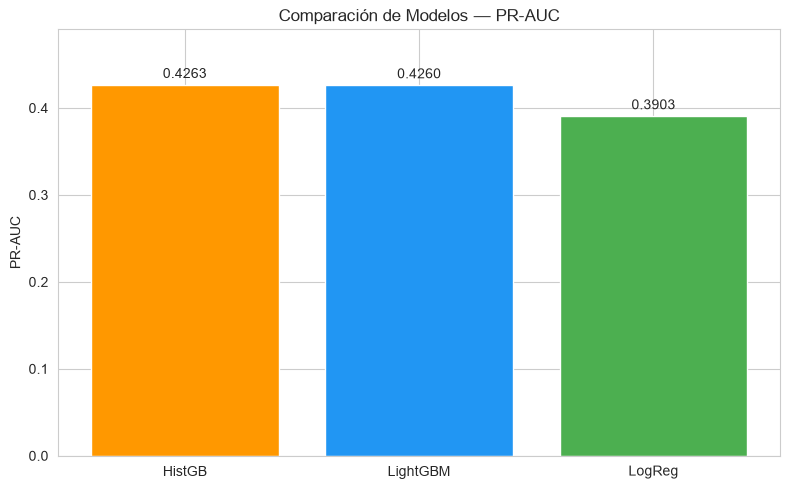

In [19]:
from sklearn.metrics import precision_score, recall_score

def global_metrics_at_threshold(y_true, y_prob, threshold):
    """Calcula precision, recall y F1 global en un umbral dado."""
    y_pred = (y_prob >= threshold).astype(int)
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return p, r, f1

results = []
for name, (pr_auc, y_prob) in model_scores.items():
    roc  = roc_auc_score(y_val, y_prob)
    p, r, f1 = global_metrics_at_threshold(y_val, y_prob, best_thresh)
    results.append({
        'Modelo': name,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc,
        f'Precision@{best_thresh:.2f}': p,
        f'Recall@{best_thresh:.2f}': r,
        f'F1@{best_thresh:.2f}': f1
    })

df_results = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)
print("Comparación de modelos:")
print(df_results.to_string(index=False, float_format='{:.4f}'.format))

# Barplot PR-AUC
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_results['Modelo'], df_results['PR-AUC'],
              color=['#FF9800', '#2196F3', '#4CAF50'][:len(df_results)])
ax.bar_label(bars, fmt='{:.4f}', padding=3)
ax.set_title('Comparación de Modelos — PR-AUC')
ax.set_ylabel('PR-AUC')
ax.set_ylim(0, max(df_results['PR-AUC']) * 1.15)
plt.tight_layout()
plt.show()

## Sección 12: Interpretabilidad — Feature Importance

Analizamos la importancia de las features en LightGBM usando dos métricas:

- **Gain**: reducción total de la función de pérdida (impurity) atribuida a cada feature. Es la métrica más informativa sobre qué features ayudan realmente a las predicciones.
- **Split**: número de veces que se usó la feature para hacer un split. Puede sobreestimar features de alta cardinalidad.

**Sanity check de no-leakage**: si el modelo funciona bien sin leakage, esperamos ver features `up_*` (usuario-producto) en el top, ya que son las más directamente relacionadas con la fidelidad del usuario a cada producto. Si aparecen features del carrito `train` en el top, habría leakage.

Top-15 features por Gain (LightGBM):
             feature  importance_gain  importance_split
up_orders_since_last     2.215249e+07               806
       up_order_rate     8.497243e+06              1025
         up_n_orders     4.964706e+06               235
  up_days_since_last     2.357592e+06              1607
            aisle_id     2.099512e+06              6615
      p_reorder_rate     2.004250e+06               713
      u_reorder_rate     8.715296e+05              1160
        o_days_since     5.652679e+05               832
            cf_score     4.621673e+05               538
  up_first_order_num     3.484469e+05               544
          p_n_orders     3.073196e+05               376
          u_avg_days     1.613773e+05               598
           p_n_users     1.385759e+05               408
   up_last_order_num     1.285711e+05               252
      p_avg_cart_pos     1.103033e+05               393

Top-5 features: ['up_orders_since_last', 'up_order_rate', 'up_n_or

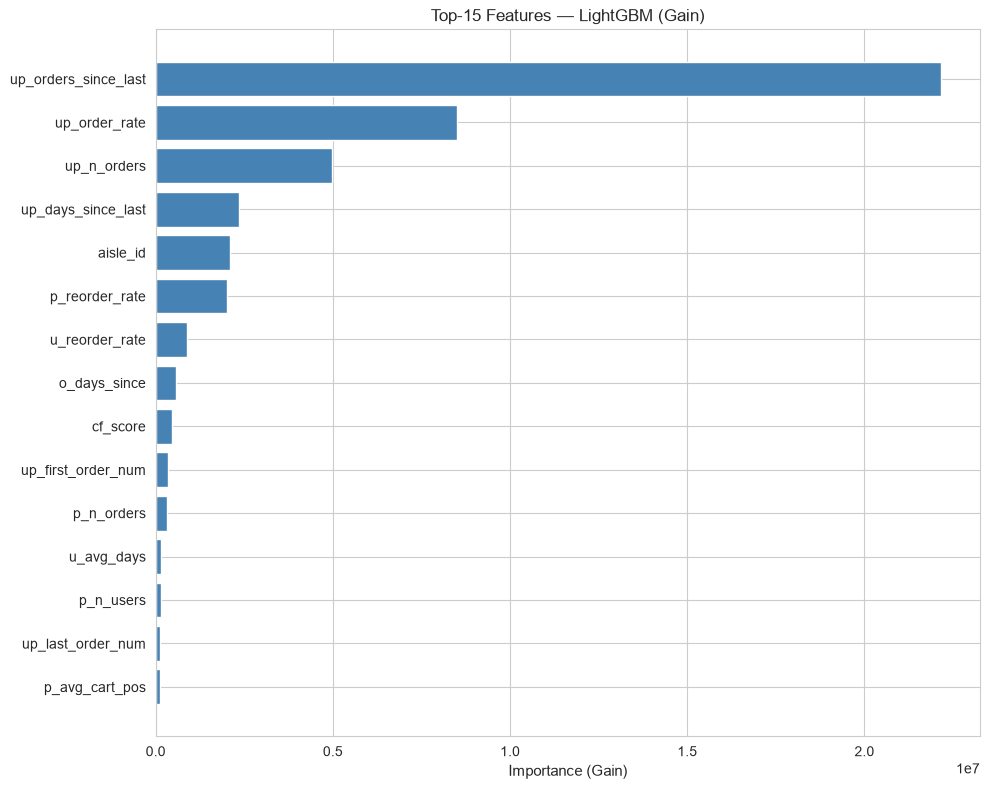

Guardado: reorder_feature_importance.csv


In [20]:
# Feature importance de LightGBM (nativo, más rápido que permutation importance)
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance_gain': lgbm.booster_.feature_importance(importance_type='gain'),
    'importance_split': lgbm.booster_.feature_importance(importance_type='split')
}).sort_values('importance_gain', ascending=False).reset_index(drop=True)

print("Top-15 features por Gain (LightGBM):")
print(feat_imp.head(15)[['feature','importance_gain','importance_split']].to_string(index=False))

# Sanity check: top features deberían ser up_* (no leakage)
top_5_features = feat_imp.head(5)['feature'].tolist()
print(f"\nTop-5 features: {top_5_features}")
up_in_top5 = sum(1 for f in top_5_features if f.startswith('up_'))
print(f"Features up_* en el top-5: {up_in_top5}/5 ({'OK - no leakage' if up_in_top5 >= 2 else 'Revisar'})")

# Gráfico horizontal
fig, ax = plt.subplots(figsize=(10, 8))
top15 = feat_imp.head(15)
ax.barh(top15['feature'][::-1], top15['importance_gain'][::-1], color='steelblue')
ax.set_xlabel('Importance (Gain)', fontsize=11)
ax.set_title('Top-15 Features — LightGBM (Gain)', fontsize=12)
plt.tight_layout()
plt.show()

feat_imp.to_csv(os.path.join(PROCESSED_DIR, 'reorder_feature_importance.csv'), index=False)
print("Guardado: reorder_feature_importance.csv")

## Sección 13: Análisis Cualitativo — Ejemplos de Predicción por Usuario

Para 5 usuarios aleatorios del val set, comparamos:

- **Carrito REAL**: productos que el usuario realmente compró en su pedido `train`.
- **Carrito PREDICHO**: productos clasificados como positivos en el umbral óptimo.
- **Hits**: productos que acertamos (intersección entre real y predicho).
- **Precision y Recall individuales**: para entender si el modelo es más conservador (pocos preds) o agresivo (muchos preds).

Este análisis cualitativo complementa las métricas cuantitativas: permite detectar si el modelo falla sistemáticamente en ciertos tipos de usuarios o productos.

In [21]:
if sys.stdout.encoding and sys.stdout.encoding.lower() != 'utf-8':
    try:
        sys.stdout.reconfigure(encoding='utf-8', errors='replace')
    except Exception:
        pass

product_name_map = products.set_index('product_id')['product_name'].to_dict()

def safe_name(pid):
    """Retorna nombre del producto con fallback seguro."""
    name = product_name_map.get(int(pid), str(pid))
    try:
        return name.encode('utf-8').decode('utf-8')
    except Exception:
        return name.encode('ascii', 'replace').decode('ascii')

# 5 usuarios aleatorios del val set
rng2 = np.random.RandomState(0)
sample_users = rng2.choice(list(val_users), size=5, replace=False)

# DataFrame de val con probabilidades y predicciones
df_val_with_prob = df_val[['user_id','product_id','reordered']].copy()
df_val_with_prob['prob'] = best_probs
df_val_with_prob['pred'] = (best_probs >= best_thresh).astype(int)

print(f"Modelo: {best_model_name} | Umbral: {best_thresh:.3f}")
print("=" * 70)

for uid in sample_users:
    user_df = df_val_with_prob[df_val_with_prob['user_id'] == uid].sort_values('prob', ascending=False)
    carrito_real = user_df[user_df['reordered'] == 1]['product_id'].values
    carrito_pred = user_df[user_df['pred'] == 1]['product_id'].values

    hits = len(set(carrito_real) & set(carrito_pred))
    precision_u = hits / max(len(carrito_pred), 1)
    recall_u    = hits / max(len(carrito_real), 1)

    print(f"\n--- Usuario {uid} ---")
    print(f"  Carrito REAL  ({len(carrito_real)} prods): "
          f"{[safe_name(p)[:35] for p in carrito_real[:5]]}")
    print(f"  Carrito PRED  ({len(carrito_pred)} prods): "
          f"{[safe_name(p)[:35] for p in carrito_pred[:5]]}")
    print(f"  Hits: {hits} | Precision: {precision_u:.2f} | Recall: {recall_u:.2f}")

Modelo: HistGB | Umbral: 0.690

--- Usuario 205418 ---
  Carrito REAL  (10 prods): ['Banana', '100% Whole Wheat Bread', 'Premium Apple Juice', 'Eggo Chocolate Chip Pancakes 12 Cou', 'Original Thin Pepperoni Pizza']
  Carrito PRED  (12 prods): ['Banana', '100% Whole Wheat Bread', 'Premium Apple Juice', 'Eggo Chocolate Chip Pancakes 12 Cou', 'Original Thin Pepperoni Pizza']
  Hits: 9 | Precision: 0.75 | Recall: 0.90

--- Usuario 114910 ---
  Carrito REAL  (2 prods): ['Organic Lemon', 'Sparkling Water Grapefruit']
  Carrito PRED  (2 prods): ['Asparagus', 'Organic Reduced Fat 2% Milk']
  Hits: 0 | Precision: 0.00 | Recall: 0.00

--- Usuario 119417 ---
  Carrito REAL  (4 prods): ['Whole Wheat Fresh Stack Crackers', 'Whole Wheat Fig Bar', 'Apples & Cinnamon Instant Oatmeal', 'Garden Veggie Straws Sea Salt']
  Carrito PRED  (16 prods): ['Organic Triple Berry Blend', 'ALMONDBREEZE UNSWEETENED', 'Whole Wheat Fresh Stack Crackers', 'Bag of Organic Bananas', 'Whole Wheat Fig Bar']
  Hits: 3 | Pre

## Sección 14: Persistencia de Artefactos

Guardamos todos los artefactos generados para uso en producción, reportes y notebooks posteriores:

| Artefacto | Descripción |
|-----------|-------------|
| `reorder_best_model.joblib` | Objeto del mejor modelo para inferencia directa |
| `reorder_logreg.joblib` | Pipeline de Regresión Logística (baseline lineal) |
| `reorder_metrics.csv` | Tabla comparativa de métricas de los 3 modelos |
| `reorder_predictions.parquet` | Probabilidades y predicciones del val set |
| `reorder_feature_importance.csv` | Ranking de features por Gain y Split |

In [22]:
# Determinar mejor modelo objeto
model_objects = {
    'LogReg': lr_pipeline,
    'HistGB': hgb,
    'LightGBM': lgbm,
}
best_obj = model_objects[best_model_name]

# Guardar mejor modelo
joblib.dump(best_obj, os.path.join(MODELS_DIR, 'reorder_best_model.joblib'))
# Guardar también la Regresión Logística (baseline lineal documentado)
joblib.dump(lr_pipeline, os.path.join(MODELS_DIR, 'reorder_logreg.joblib'))

# Guardar métricas
df_results.to_csv(os.path.join(PROCESSED_DIR, 'reorder_metrics.csv'), index=False)

# Guardar predicciones del val set
df_val_with_prob[['user_id','product_id','prob','pred']].to_parquet(
    os.path.join(PROCESSED_DIR, 'reorder_predictions.parquet'), index=False)

# Guardar umbral óptimo y nombre del mejor modelo
metadata = {
    'best_model_name': best_model_name,
    'best_threshold': float(best_thresh),
    'best_f1_mean_per_order': float(best_f1_mean),
    'feature_cols': feature_cols
}
joblib.dump(metadata, os.path.join(MODELS_DIR, 'reorder_metadata.joblib'))

# Reporte de artefactos guardados
print("Artefactos guardados:")
processed_files = [
    'reorder_metrics.csv',
    'reorder_predictions.parquet',
    'reorder_feature_importance.csv',
]
for fname in processed_files:
    fpath = os.path.join(PROCESSED_DIR, fname)
    if os.path.exists(fpath):
        sz = os.path.getsize(fpath) / 1024
        unit = 'KB'
        if sz > 1024:
            sz /= 1024
            unit = 'MB'
        print(f"  [OK] {fname:<45} {sz:>7.1f} {unit}")
    else:
        print(f"  [!!] {fname} — NO encontrado")

model_files = [
    'reorder_best_model.joblib',
    'reorder_logreg.joblib',
    'reorder_metadata.joblib',
]
for fname in model_files:
    fpath = os.path.join(MODELS_DIR, fname)
    if os.path.exists(fpath):
        sz = os.path.getsize(fpath) / 1024 / 1024
        print(f"  [OK] {fname:<45} {sz:>7.1f} MB")
    else:
        print(f"  [!!] {fname} — NO encontrado")

print(f"\nMejor modelo   : {best_model_name}")
print(f"Umbral óptimo  : {best_thresh:.3f}")
print(f"F1 medio pedido: {best_f1_mean:.4f}")
print(f"PR-AUC         : {model_scores[best_model_name][0]:.4f}")
print(f"ROC-AUC        : {roc_auc_score(y_val, best_probs):.4f}")

Artefactos guardados:
  [OK] reorder_metrics.csv                               0.4 KB
  [OK] reorder_predictions.parquet                      17.3 MB
  [OK] reorder_feature_importance.csv                    0.9 KB
  [OK] reorder_best_model.joblib                         1.7 MB
  [OK] reorder_logreg.joblib                             0.0 MB
  [OK] reorder_metadata.joblib                           0.0 MB

Mejor modelo   : HistGB
Umbral óptimo  : 0.690
F1 medio pedido: 0.3815
PR-AUC         : 0.4263
ROC-AUC        : 0.8365
